# Training the Model

In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken

import optax

In [2]:
from helper import MiniGPT, load_and_preprocess_data, generate_text

In [3]:
maxlen=128
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path='TinyStories-1000.txt',
    batch_size=32,
    maxlen=128,
    max_stories=100,
    shuffle=False,
    seed=42
)

Loading data from TinyStories-1000.txt (max 100 stories)
Loaded 100 stories
Estimated batches per epoch: 3
Created DataLoader with batch_size=32, maxlen=128


In [5]:
model = MiniGPT()

In [6]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits

In [7]:
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 9
Warmup steps: 1


In [8]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)

## Use an optimizer from optax

In [9]:
optimizer = nnx.Optimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01)
)

In [10]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

## Define and JIT-compile the training step

In [11]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)

## Run the training loop

In [12]:
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..
Epoch: 1, Step 2, Loss: 10.8881, LR: 3.00e-04
...
Epoch: 2, Step 2, Loss: 10.5748, LR: 3.00e-04
...
Epoch: 3, Step 2, Loss: 10.2045, LR: 3.00e-04
.

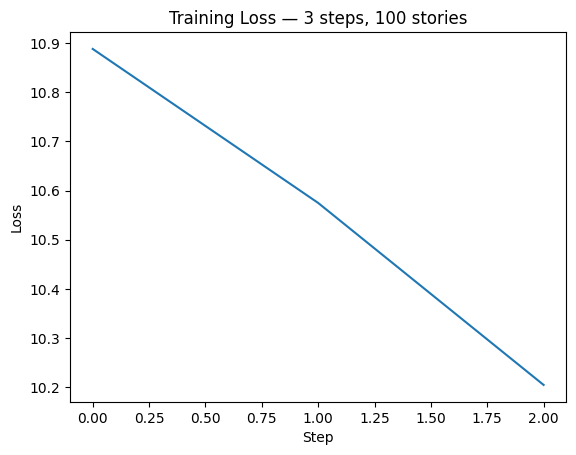

In [13]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Save model checkpoints

In [14]:
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /home/jovyan/work/L4/small_checkpoint.orbax
